#  Global Earthquake Analysis with PySpark: Nolan CACHEUX

For this project, I decided to analyze global earthquake data using PySpark on Google Colab.

I'm working with three datasets from Kaggle:
- **USGS Significant Earthquakes (1965-2016)**: 23,000+ recorded events
- **Significant Earthquakes (1900-Present)**: 112,000+ events with extended attributes
- **Countries of the World**: 227 countries with demographic and economic indicators

The idea is to find patterns in earthquake data, cross-reference it with country-level info (GDP, population, region), and put into practice everything from Labs 3.x: schemas, transformations, actions, SQL, joins, and more.


## Table of Contents

1. [Environment Setup](#1.-Environment-Setup)
2. [SparkSession Creation](#2.-SparkSession-Creation)
3. [Ngrok Tunnel for Spark UI](#3.-Ngrok-Tunnel-for-Spark-UI)
4. [Dataset Download](#4.-Dataset-Download)
5. [Schema Declaration](#5.-Schema-Declaration)
6. [Loading Data](#6.-Loading-Data)
7. [Initial Exploration](#7.-Initial-Exploration)
8. [Data Cleaning](#8.-Data-Cleaning)
9. [Date and Time Conversion](#9.-Date-and-Time-Conversion)
10. [Filters](#10.-Filters)
11. [Calculated Columns and Feature Engineering](#11.-Calculated-Columns-and-Feature-Engineering)
12. [Aggregations](#12.-Aggregations)
13. [Union: Combining DataFrames](#13.-Union:-Combining-DataFrames)
14. [Joins: Enriching with Country Data](#14.-Joins:-Enriching-with-Country-Data)
15. [Spark SQL](#15.-Spark-SQL)
16. [Advanced Functions: Beyond the Course](#16.-Advanced-Functions:-Beyond-the-Course)
17. [Visualizations](#17.-Visualizations)
18. [Spark UI: DAG Analysis](#18.-Spark-UI:-DAG-Analysis)
19. [Key Findings](#19.-Key-Findings)
20. [Conclusion](#Conclusion)


In [ ]:
# Credentials: fill these before running
NGROK_TOKEN = "YOUR_NGROK_TOKEN"
KAGGLE_API_TOKEN = "YOUR_KAGGLE_API_TOKEN"


## 1. Environment Setup

Colab doesn't have Spark out of the box, so the first step is installing everything we need. We covered this setup process in Lab 3.1.

First things first: I need to install Java and Spark on Colab since they're not pre-installed.

In [ ]:
# Install Java and Spark (ref Lab 3.1)
# Modern Colab comes with Java 11+ which Spark 3.5.x supports
!apt-get install openjdk-11-jdk-headless -qq > /dev/null 2>&1 || true
!wget -q https://archive.apache.org/dist/spark/spark-3.5.8/spark-3.5.8-bin-hadoop3.tgz
!tar xf spark-3.5.8-bin-hadoop3.tgz
!pip install -q findspark pyngrok


Setting up the environment variables so Python can find Java and Spark.

In [ ]:
import os, glob

# Auto-detect Java installation (works with Java 8, 11, or 17)
java_candidates = glob.glob("/usr/lib/jvm/java-*-openjdk-amd64")
if java_candidates:
    os.environ["JAVA_HOME"] = sorted(java_candidates)[-1]  # pick latest
else:
    os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

os.environ["SPARK_HOME"] = "/content/spark-3.5.8-bin-hadoop3"

import findspark
findspark.init()

print(f"JAVA_HOME: {os.environ['JAVA_HOME']}")
print(f"SPARK_HOME: {os.environ['SPARK_HOME']}")


## 2. SparkSession Creation

As explained in Chapter 3.0, Spark runs on a Driver + Executors architecture. The Driver is my Python process that orchestrates everything, and the Executors run the actual computation in parallel. Since I'm on Colab, I use `local[*]` which runs everything in one JVM using all available CPU cores.

The `SparkSession` is the unified entry point introduced in Spark 2.x: it replaces the older SparkContext/SQLContext combo.

Creating the Spark session. I'm using `local[*]` to use all available cores on the Colab machine.

In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("EarthquakeAnalysis")
    .config("spark.ui.port", "4050")
    .getOrCreate()
)

spark.conf.set("spark.sql.repl.eagerEval.enabled", True)

print(f"Spark version : {spark.version}")
print(f"Spark UI      : http://localhost:4050")

## 3. Ngrok Tunnel for Spark UI

I need ngrok here because Colab doesn't expose local ports. This creates a public tunnel to port 4050 so I can inspect jobs, stages, and the DAG directly in the browser (Lab 3.1).

In [ ]:
from pyngrok import ngrok

# Authenticate with ngrok
ngrok.set_auth_token(NGROK_TOKEN)

# Open a tunnel to the Spark UI
tunnel = ngrok.connect(4050)
print(f"Spark UI available at: {tunnel.public_url}")

## 4. Dataset Download

I picked three datasets that complement each other well:

| Dataset | Kaggle slug | What it gives me | Rows |
|---------|-------------|-----------------|------|
| USGS Earthquake Database | `usgs/earthquake-database` | Detailed seismic data, 1965-2016 | ~23,000 |
| Significant Earthquakes | `usamabuttar/significant-earthquakes` | Extended catalog, 1900-present | ~112,000 |
| Countries of the World | `fernandol/countries-of-the-world` | GDP, population, region per country | 227 |

The idea is to combine seismic data with country-level info to study seismic risk in an economic context.

Downloading all three datasets from Kaggle directly into the Colab environment.

In [ ]:
import os

# Configure Kaggle via environment variables (simpler than writing JSON)
os.environ['KAGGLE_USERNAME'] = 'YOUR_KAGGLE_USERNAME'
os.environ['KAGGLE_KEY'] = KAGGLE_API_TOKEN

# Download the three datasets
!kaggle datasets download -d usgs/earthquake-database       --unzip -p /content/data/usgs      -q
!kaggle datasets download -d usamabuttar/significant-earthquakes --unzip -p /content/data/sig   -q
!kaggle datasets download -d fernandol/countries-of-the-world    --unzip -p /content/data/countries -q

print("All 3 datasets downloaded.")


Quick look at the raw CSV files to understand what I'm working with before defining schemas.

In [ ]:
# Preview the first 3 lines of each CSV to inspect headers and data format
!head -n 3 /content/data/usgs/database.csv

!head -n 3 /content/data/sig/Significant_Earthquakes.csv

!head -n 3 /content/data/countries/countries\ of\ the\ world.csv

## 5. Schema Declaration

One thing I took away from Lab 3.5 is that you should always declare your schema manually. I used to just set `inferSchema=True` but that triggers a full extra scan of the data just to guess types, and it can silently get things wrong (like reading a ZIP code as an integer). Explicit schemas also serve as documentation and catch data drift early.

Defining the schema manually for the USGS dataset. I checked the CSV headers and picked the right types for each column.

In [ ]:
from pyspark.sql.types import *

# Schema for USGS Earthquake Database (database.csv)
usgs_schema = StructType([
    StructField("Date", StringType(), True),
    StructField("Time", StringType(), True),
    StructField("Latitude", DoubleType(), True),
    StructField("Longitude", DoubleType(), True),
    StructField("Type", StringType(), True),
    StructField("Depth", DoubleType(), True),
    StructField("Depth_Error", DoubleType(), True),
    StructField("Depth_Seismic_Stations", IntegerType(), True),
    StructField("Magnitude", DoubleType(), True),
    StructField("Magnitude_Type", StringType(), True),
    StructField("Magnitude_Error", DoubleType(), True),
    StructField("Magnitude_Seismic_Stations", IntegerType(), True),
    StructField("Azimuthal_Gap", DoubleType(), True),
    StructField("Horizontal_Distance", DoubleType(), True),
    StructField("Horizontal_Error", DoubleType(), True),
    StructField("Root_Mean_Square", DoubleType(), True),
    StructField("ID", StringType(), True),
    StructField("Source", StringType(), True),
    StructField("Location_Source", StringType(), True),
    StructField("Magnitude_Source", StringType(), True),
    StructField("Status", StringType(), True),
])

print(f"USGS schema: {len(usgs_schema.fields)} fields")

Same thing for the second earthquake dataset. Note the extra index column at the start that I'll drop later.

In [ ]:
# Schema for Significant Earthquakes (Significant_Earthquakes.csv)
# Note: this CSV has an index column as the first field
sig_schema = StructType([
    StructField("_index", IntegerType(), True),
    StructField("time", StringType(), True),
    StructField("latitude", DoubleType(), True),
    StructField("longitude", DoubleType(), True),
    StructField("depth", DoubleType(), True),
    StructField("mag", DoubleType(), True),
    StructField("magType", StringType(), True),
    StructField("nst", IntegerType(), True),
    StructField("gap", DoubleType(), True),
    StructField("dmin", DoubleType(), True),
    StructField("rms", DoubleType(), True),
    StructField("net", StringType(), True),
    StructField("id", StringType(), True),
    StructField("updated", StringType(), True),
    StructField("place", StringType(), True),
    StructField("type", StringType(), True),
    StructField("horizontalError", DoubleType(), True),
    StructField("depthError", DoubleType(), True),
    StructField("magError", DoubleType(), True),
    StructField("magNst", IntegerType(), True),
    StructField("status", StringType(), True),
    StructField("locationSource", StringType(), True),
    StructField("magSource", StringType(), True),
])

print(f"Significant Earthquakes schema: {len(sig_schema.fields)} fields")

Schema for the countries dataset. Some numeric columns use European comma format, so I'm reading them as strings for now and I'll convert them later.

In [ ]:
# Schema for Countries of the World
countries_schema = StructType([
    StructField("Country", StringType(), True),
    StructField("Region", StringType(), True),
    StructField("Population", IntegerType(), True),
    StructField("Area", IntegerType(), True),
    StructField("Pop_Density", StringType(), True),
    StructField("Coastline", StringType(), True),
    StructField("Net_migration", StringType(), True),
    StructField("Infant_mortality", StringType(), True),
    StructField("GDP", IntegerType(), True),
    StructField("Literacy", StringType(), True),
    StructField("Phones", StringType(), True),
    StructField("Arable", StringType(), True),
    StructField("Crops", StringType(), True),
    StructField("Other", StringType(), True),
    StructField("Climate", StringType(), True),
    StructField("Birthrate", StringType(), True),
    StructField("Deathrate", StringType(), True),
    StructField("Agriculture", StringType(), True),
    StructField("Industry", StringType(), True),
    StructField("Service", StringType(), True),
])

print(f"Countries schema: {len(countries_schema.fields)} fields")

I'm using `PERMISSIVE` mode here (Lab 3.6) which keeps all rows even when some fields don't match the schema: bad values become `null` instead of dropping the entire row. The alternative `DROPMALFORMED` silently discards rows, which can cause unexpected data loss when Spark fully materializes the DataFrame. `FAILFAST` would throw an error immediately, but that's too strict for real-world data.


Loading all three CSVs with the schemas I just defined. Using PERMISSIVE to skip any broken rows.

In [ ]:
# Load USGS Earthquake Database
df_usgs = (
    spark.read
    .format("csv")
    .option("header", "true")
    .option("mode", "PERMISSIVE")
    .schema(usgs_schema)
    .load("/content/data/usgs/database.csv")
)

# Load Significant Earthquakes
df_sig = (
    spark.read
    .format("csv")
    .option("header", "true")
    .option("mode", "PERMISSIVE")
    .schema(sig_schema)
    .load("/content/data/sig/Significant_Earthquakes.csv")
)

# Load Countries of the World
df_countries = (
    spark.read
    .format("csv")
    .option("header", "true")
    .option("mode", "PERMISSIVE")
    .schema(countries_schema)
    .load("/content/data/countries/countries of the world.csv")
)

print("All 3 DataFrames loaded successfully.")

## 7. Initial Exploration

This is where I verify that my data loaded correctly. As covered in Lab 3.4, everything I do here (`count()`, `printSchema()`, `describe()`, `show()`) are **actions**: they trigger actual computation. All the loading, filtering, and schema stuff above were just **transformations** (lazy), meaning Spark hadn't actually read any data yet.

Let me check how many rows loaded and what the data looks like. These are all actions, so this is where Spark actually reads the files.

In [ ]:
#  USGS Earthquake Database 
print(f"df_usgs row count: {df_usgs.count():,}")
print()

df_usgs.printSchema()

# Statistical summary of numeric columns
df_usgs.describe().show()

# Preview first 5 rows
df_usgs.show(5, truncate=False)

Same checks for the other two datasets.

In [ ]:
#  Significant Earthquakes 
print(f"df_sig row count: {df_sig.count():,}")
print()
df_sig.printSchema()
df_sig.show(5, truncate=False)

#  Countries of the World 
print(f"\ndf_countries row count: {df_countries.count():,}")
print()
df_countries.printSchema()
df_countries.show(5, truncate=False)

## 8. Data Cleaning

Before doing anything with the data, I need to clean it up. Bad data leads to bad results. I'm applying the concepts from Lab 3.6: checking for nulls, removing duplicates, and filtering out invalid records. My approach is to be aggressive with cleaning: I'd rather have a smaller, reliable dataset than a large noisy one.

Checking for missing values in the USGS dataset to understand data quality.

In [ ]:
# Count null values per column for USGS dataset
from pyspark.sql.functions import *

null_counts = df_usgs.select([count(when(col(c).isNull(), c)).alias(c) for c in df_usgs.columns])
null_counts.show(vertical=True)

Same null check for the significant earthquakes dataset.

In [ ]:
# Count null values per column for Significant Earthquakes dataset
null_counts_sig = df_sig.select([count(when(col(c).isNull(), c)).alias(c) for c in df_sig.columns])
null_counts_sig.show(vertical=True)

Cleaning the USGS dataset: dropping duplicates, keeping only real earthquakes (filtering out nuclear explosions and quarry blasts), and removing rows with missing key values. I also filter out non-positive magnitudes and negative depths.


In [ ]:
# Clean USGS dataset: remove duplicates, keep only earthquakes, drop nulls in key columns
df_usgs_clean = (df_usgs
    .dropDuplicates()
    .filter(col("Type") == "Earthquake")
    .dropna(subset=["Magnitude", "Latitude", "Longitude"])
    .filter((col("Magnitude") > 0) & (col("Depth") >= 0))
)
print(f"USGS: {df_usgs.count()} -> {df_usgs_clean.count()} after cleaning")

Applying the same cleaning logic to the significant earthquakes dataset: deduplication by ID, keeping only earthquake types, and dropping the unnecessary index column.


In [ ]:
# Clean Significant Earthquakes dataset
df_sig_clean = (df_sig
    .dropDuplicates(["id"])
    .filter(col("type") == "earthquake")
    .dropna(subset=["mag", "latitude", "longitude"])
    .filter((col("mag") > 0))
    .drop("_index")
)
print(f"Significant: {df_sig.count()} -> {df_sig_clean.count()} after cleaning")

The countries dataset needs special treatment: trimming whitespace and converting European decimal format (commas to dots).

In [ ]:
# Clean Countries dataset: trim whitespace, convert European decimal format (comma -> dot)
df_countries_clean = (df_countries
    .withColumn("Country", trim(col("Country")))
    .withColumn("Region", trim(col("Region")))
    .withColumn("Pop_Density_num", regexp_replace(col("Pop_Density"), ",", ".").cast(DoubleType()))
    .withColumn("Coastline_num", regexp_replace(col("Coastline"), ",", ".").cast(DoubleType()))
    .withColumn("GDP_per_capita", col("GDP").cast(IntegerType()))
    .dropna(subset=["Country", "Population"])
)
df_countries_clean.show(5)

## 9. Date and Time Conversion

Handling dates is one of those things that's always messier than you'd expect. My USGS data uses American format `MM/DD/YYYY` with a separate time column, while the Significant dataset uses ISO 8601 (`yyyy-MM-dd'T'HH:mm:ss.SSS'Z'`). PySpark's `to_timestamp()` and `to_date()` handle this well once you give them the right format pattern (Lab 3.7).

I'm also extracting Year, Month, Hour, and Decade for temporal analysis later.

Converting the USGS date and time columns into proper Spark timestamp and date types. I also extract Year, Month, and Decade for temporal analysis later.


In [ ]:
# Convert USGS date strings to proper date/timestamp types
df_usgs_clean = (df_usgs_clean
    .withColumn("DateTime", to_timestamp(concat_ws(" ", col("Date"), col("Time")), "MM/dd/yyyy HH:mm:ss"))
    .withColumn("EventDate", to_date(col("Date"), "MM/dd/yyyy"))
    .withColumn("Year", year(col("EventDate")))
    .withColumn("Month", month(col("EventDate")))
    .withColumn("Decade", (floor(col("Year") / 10) * 10).cast(IntegerType()))
)
df_usgs_clean.select("Date", "Time", "DateTime", "EventDate", "Year", "Month", "Decade").show(5)

Same date conversion for the significant earthquakes dataset. This one uses ISO 8601 format, but some entries have milliseconds and others don't, so I use `coalesce()` to try multiple patterns and keep all rows.


In [ ]:
# Convert Significant Earthquakes ISO date strings to proper date/timestamp types
# Some dates have milliseconds (.SSS), others don't, so I try both patterns with coalesce
df_sig_clean = (df_sig_clean
    .withColumn("DateTime", coalesce(
        to_timestamp(col("time"), "yyyy-MM-dd'T'HH:mm:ss.SSS'Z'"),
        to_timestamp(col("time"), "yyyy-MM-dd'T'HH:mm:ss'Z'"),
        to_timestamp(col("time"))
    ))
    .withColumn("EventDate", to_date(col("DateTime")))
    .withColumn("Year", year(col("DateTime")))
    .withColumn("Month", month(col("DateTime")))
    .withColumn("DayOfWeek", dayofweek(col("DateTime")))
    .withColumn("Hour", hour(col("DateTime")))
    .withColumn("Decade", (floor(col("Year") / 10) * 10).cast(IntegerType()))
)
df_sig_clean.select("time", "DateTime", "Year", "Month", "Hour", "Decade").show(5)
print(f"Rows with valid DateTime: {df_sig_clean.filter(col('DateTime').isNotNull()).count()} / {df_sig_clean.count()}")


## 10. Filters

Filters are a good example of how lazy evaluation works in practice (Lab 3.4). When I chain multiple `.filter()` calls, Spark doesn't execute them one by one: it builds a DAG and optimizes the whole thing. Filters are narrow transformations (no shuffle), which makes them very fast.

Filtering for major earthquakes (magnitude 7+) to see how many truly large events there are.

In [ ]:
# Filter major earthquakes (magnitude >= 7.0)
df_major = df_sig_clean.filter(col("mag") >= 7.0)
print(f"Major earthquakes (M>=7): {df_major.count()} out of {df_sig_clean.count()}")
df_major.orderBy(col("mag").desc()).select("time", "place", "mag", "depth").show(10)

Filtering for earthquakes in Pacific Ring of Fire countries to see how dominant that region is.

In [ ]:
# Filter earthquakes in the Pacific Ring of Fire region
df_pacific = df_sig_clean.filter(
    (col("place").contains("Japan")) |
    (col("place").contains("Indonesia")) |
    (col("place").contains("Chile")) |
    (col("place").contains("Alaska")) |
    (col("place").contains("Philippines")) |
    (col("place").contains("New Zealand")) |
    (col("place").contains("Mexico"))
)
print(f"Pacific Ring of Fire earthquakes: {df_pacific.count()}")

Isolating 21st century earthquakes to compare modern detection with historical data.

In [ ]:
# Filter 21st century earthquakes only
df_21st = df_sig_clean.filter(col("Year") >= 2000)
print(f"21st century earthquakes: {df_21st.count()}")

Classifying earthquakes by depth. Shallow ones are generally the most dangerous for people on the surface.

In [ ]:
# Classify earthquakes by depth: shallow, intermediate, deep
df_shallow = df_sig_clean.filter(col("depth") < 70)
df_intermediate = df_sig_clean.filter((col("depth") >= 70) & (col("depth") < 300))
df_deep = df_sig_clean.filter(col("depth") >= 300)

print(f"Shallow (<70km): {df_shallow.count()}")
print(f"Intermediate (70-300km): {df_intermediate.count()}")
print(f"Deep (>300km): {df_deep.count()}")

## 11. Calculated Columns and Feature Engineering

This part is where the analysis starts getting interesting. I'm creating new columns that don't exist in the raw data but add real analytical value (Lab 3.7). The Gutenberg-Richter energy formula ($E = 10^{1.5M + 4.8}$) converts magnitude into actual energy in Joules, which gives a much better sense of scale: a magnitude 9 earthquake releases about 32x more energy than a magnitude 8.

This is where I add the most interesting calculated columns: seismic energy using the Gutenberg-Richter formula, magnitude categories, and a tsunami risk flag.

In [ ]:
# Add seismic energy (Gutenberg-Richter), magnitude category, depth category, tsunami risk flag
import math

df_enriched = (df_sig_clean
    .withColumn("Energy_Joules", pow(lit(10), 1.5 * col("mag") + 4.8))
    .withColumn("Magnitude_Category",
        when(col("mag") >= 8.0, "Great (8+)")
        .when(col("mag") >= 7.0, "Major (7-7.9)")
        .when(col("mag") >= 6.0, "Strong (6-6.9)")
        .when(col("mag") >= 5.0, "Moderate (5-5.9)")
        .otherwise("Light (<5)"))
    .withColumn("Depth_Category",
        when(col("depth") < 70, "Shallow")
        .when(col("depth") < 300, "Intermediate")
        .otherwise("Deep"))
    .withColumn("Is_Tsunami_Depth",
        when((col("depth") < 100) & (col("mag") >= 7.0), True).otherwise(False))
)
df_enriched.select("place", "mag", "depth", "Magnitude_Category", "Depth_Category", "Energy_Joules", "Is_Tsunami_Depth").show(10, truncate=False)

Extracting the country name from the place string. Most entries look like '120 km NW of Tokyo, Japan', so I grab whatever comes after the last comma.

In [ ]:
# Extract country/region from the place string (text after last comma)
df_enriched = df_enriched.withColumn(
    "Country_Extracted",
    when(col("place").contains(","), trim(element_at(split(col("place"), ","), -1)))
    .otherwise(col("place"))
)
df_enriched.select("place", "Country_Extracted").show(10, truncate=False)

Adding geographic features: hemisphere, longitude zone, and distance from the equator. These help with regional analysis later.

In [ ]:
# Add geographic features: distance from equator, hemisphere, longitude zone
df_enriched = (df_enriched
    .withColumn("Distance_From_Equator", abs(col("latitude")))
    .withColumn("Hemisphere",
        when(col("latitude") >= 0, "Northern").otherwise("Southern"))
    .withColumn("Longitude_Zone",
        when(col("longitude") < -30, "Americas")
        .when(col("longitude") < 30, "Europe/Africa")
        .when(col("longitude") < 100, "Middle East/Asia")
        .otherwise("Pacific/Oceania"))
)
df_enriched.select("latitude", "longitude", "Hemisphere", "Longitude_Zone", "Distance_From_Equator").show(10)

Since I reuse `df_enriched` throughout the rest of the notebook (aggregations, joins, SQL, visualizations), I cache it in memory. Without caching, Spark would re-read and re-transform the CSV from scratch every time I call an action. This is a direct application of Lab 3.4 on persistence.


In [ ]:
# Cache the enriched DataFrame since it's reused in all subsequent sections
df_enriched.cache()
print(f"df_enriched cached: {df_enriched.count():,} rows")

## 12. Aggregations

Now we can actually start pulling insights from the data. I'm using `groupBy()` with multiple aggregate functions in a single `agg()` call, which is more efficient than running separate queries (Labs 3.4 and 3.7).

Aggregating by decade to see how earthquake detection has evolved over time.

In [ ]:
# Earthquakes per decade with key statistics
decade_stats = (df_enriched
    .groupBy("Decade")
    .agg(
        count("*").alias("Total_Earthquakes"),
        round(avg("mag"), 2).alias("Avg_Magnitude"),
        round(max("mag"), 1).alias("Max_Magnitude"),
        round(avg("depth"), 1).alias("Avg_Depth"),
        sum(when(col("mag") >= 7.0, 1).otherwise(0)).alias("Major_Earthquakes")
    )
    .orderBy("Decade")
)
decade_stats.show()

Finding the most seismically active countries. Indonesia and Japan should be at the top.

In [ ]:
# Top 15 most seismically active countries
country_stats = (df_enriched
    .groupBy("Country_Extracted")
    .agg(
        count("*").alias("Total_Quakes"),
        round(avg("mag"), 2).alias("Avg_Mag"),
        round(max("mag"), 1).alias("Max_Mag"),
        round(avg("depth"), 1).alias("Avg_Depth"),
        round(sum("Energy_Joules"), 2).alias("Total_Energy")
    )
    .orderBy(col("Total_Quakes").desc())
)
country_stats.show(15, truncate=False)

Breaking down the data by magnitude category to see the distribution.

In [ ]:
# Aggregation by magnitude category
mag_cat_stats = (df_enriched
    .groupBy("Magnitude_Category")
    .agg(
        count("*").alias("Count"),
        round(avg("depth"), 1).alias("Avg_Depth"),
        round(avg("Energy_Joules"), 2).alias("Avg_Energy")
    )
    .orderBy(col("Count").desc())
)
mag_cat_stats.show()

Checking if earthquakes follow any seasonal pattern. Spoiler: they don't.

In [ ]:
# Monthly distribution — are earthquakes seasonal?
monthly_stats = (df_enriched
    .groupBy("Month")
    .agg(
        count("*").alias("Total"),
        round(avg("mag"), 3).alias("Avg_Mag")
    )
    .orderBy("Month")
)
monthly_stats.show(12)

Same idea but by hour of the day. Earthquakes should be uniformly distributed since they're geological, not weather-related.

In [ ]:
# Hourly distribution of earthquakes
hourly_stats = (df_enriched
    .filter(col("Hour").isNotNull())
    .groupBy("Hour")
    .agg(count("*").alias("Total"))
    .orderBy("Hour")
)
hourly_stats.show(24)

## 13. Union: Combining DataFrames

Union appends rows from one DataFrame to another. The catch is that both DataFrames must have the same columns in the same order (matched by position, not name). Since my two earthquake datasets have different schemas, I first standardize them with `select()` and `alias()` before union (Labs 3.8 and 3.10).

Before I can union the two earthquake datasets, I need to standardize their columns to match.

In [ ]:
# Standardize columns for union
df_usgs_std = (df_usgs_clean
    .select(
        col("DateTime"),
        col("Year"),
        col("Decade"),
        col("Latitude").alias("latitude"),
        col("Longitude").alias("longitude"),
        col("Depth").alias("depth"),
        col("Magnitude").alias("mag"),
        col("Magnitude_Type").alias("magType"),
        lit("usgs_1965_2016").alias("dataset_source")
    )
)

df_sig_std = (df_enriched
    .select(
        col("DateTime"),
        col("Year"),
        col("Decade"),
        col("latitude"),
        col("longitude"),
        col("depth"),
        col("mag"),
        col("magType"),
        lit("sig_1900_present").alias("dataset_source")
    )
)

df_combined = df_usgs_std.union(df_sig_std)
print(f"USGS: {df_usgs_std.count()} + Significant: {df_sig_std.count()} = Combined: {df_combined.count()}")

# Check for overlapping records (same location & time)
overlap = (df_combined
    .groupBy("DateTime", "latitude", "longitude")
    .count()
    .filter(col("count") > 1)
)
print(f"Overlapping records: {overlap.count()}")

Removing duplicate records that appear in both datasets for the overlapping time period.

In [ ]:
# Remove duplicates from combined dataset
df_unified = df_combined.dropDuplicates(["DateTime", "latitude", "longitude"])
print(f"Unified dataset: {df_unified.count()} unique earthquakes")

# Compare magnitude coverage per dataset source
df_unified.groupBy("dataset_source").agg(
    count("*").alias("Count"),
    round(avg("mag"), 2).alias("Avg_Mag"),
    min("Year").alias("Min_Year"),
    max("Year").alias("Max_Year")
).show()

## 14. Joins: Enriching with Country Data

Joins are the most powerful operation for combining datasets. I'm using a left join here so I keep all earthquakes even if they don't match a country (many earthquakes happen in the ocean or in regions that don't match country names exactly). This is covered in Lab 3.10.

Joining earthquake data with country metadata. I'm using a left join to keep all earthquakes even if the country name doesn't match perfectly.

In [ ]:
# Join earthquake data with country metadata
df_with_country = df_enriched.join(
    df_countries_clean.select("Country", "Region", "Population", "GDP_per_capita", "Area", "Coastline_num"),
    df_enriched["Country_Extracted"] == df_countries_clean["Country"],
    "left"
)

matched = df_with_country.filter(col("Region").isNotNull()).count()
total = df_with_country.count()
print(f"Matched {matched}/{total} earthquakes with country data ({matched/total*100:.1f}%)")
df_with_country.filter(col("Region").isNotNull()).select("place", "Country_Extracted", "Region", "Population", "GDP_per_capita").show(10, truncate=False)

Comparing different join types to show how they affect the result size.

In [ ]:
# Demonstrate different join types (ref Lab 3.10)

# Inner join — only matched
inner_count = df_enriched.join(df_countries_clean, df_enriched["Country_Extracted"] == df_countries_clean["Country"], "inner").count()

# Left join — all earthquakes
left_count = df_enriched.join(df_countries_clean, df_enriched["Country_Extracted"] == df_countries_clean["Country"], "left").count()

# Full outer join
full_count = df_enriched.join(df_countries_clean, df_enriched["Country_Extracted"] == df_countries_clean["Country"], "full").count()

print(f"Inner join: {inner_count} rows")
print(f"Left join:  {left_count} rows")
print(f"Full outer: {full_count} rows")

Let me inspect the physical execution plan for this join. The `explain()` output shows exactly what the Catalyst optimizer decided: scan strategy, join algorithm (broadcast vs shuffle), and filter pushdown.


In [ ]:
# Physical execution plan for the enriched join
df_with_country.explain()

Now I can analyze seismic risk by world region, combining earthquake frequency with economic data.

In [ ]:
# Seismic risk analysis by region (using joined data)
region_risk = (df_with_country
    .filter(col("Region").isNotNull())
    .groupBy("Region")
    .agg(
        count("*").alias("Total_Quakes"),
        round(avg("mag"), 2).alias("Avg_Mag"),
        round(max("mag"), 1).alias("Max_Mag"),
        countDistinct("Country_Extracted").alias("Countries_Affected"),
        round(avg("GDP_per_capita"), 0).alias("Avg_GDP")
    )
    .orderBy(col("Total_Quakes").desc())
)
region_risk.show(truncate=False)

## 15. Spark SQL

Spark SQL lets me write standard SQL queries against my DataFrames. Under the hood, both SQL and DataFrame operations go through the same Catalyst optimizer, so performance is identical. I find SQL more readable for complex queries with joins and subqueries (Lab 3.8).

Registering my DataFrames as SQL views so I can query them with standard SQL syntax.

In [ ]:
# Register DataFrames as temporary SQL views
df_enriched.createOrReplaceTempView("earthquakes")
df_countries_clean.createOrReplaceTempView("countries")
df_with_country.createOrReplaceTempView("quakes_with_country")
df_unified.createOrReplaceTempView("unified_quakes")

SQL query to find the most affected countries for strong earthquakes (magnitude 6+).

In [ ]:
# SQL Query 1 — Top 10 most affected countries (mag >= 6.0)
spark.sql("""
    SELECT Country_Extracted, 
           COUNT(*) as total_quakes,
           ROUND(AVG(mag), 2) as avg_magnitude,
           MAX(mag) as max_magnitude,
           ROUND(AVG(depth), 1) as avg_depth
    FROM earthquakes
    WHERE mag >= 6.0
    GROUP BY Country_Extracted
    ORDER BY total_quakes DESC
    LIMIT 10
""").show(truncate=False)

Tracking how the proportion of major earthquakes has changed over the decades.

In [ ]:
# SQL Query 2 — Earthquake frequency trend by decade
spark.sql("""
    SELECT Decade,
           COUNT(*) as quake_count,
           ROUND(AVG(mag), 2) as avg_mag,
           SUM(CASE WHEN mag >= 7.0 THEN 1 ELSE 0 END) as major_count,
           ROUND(SUM(CASE WHEN mag >= 7.0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as major_pct
    FROM earthquakes
    WHERE Decade IS NOT NULL
    GROUP BY Decade
    ORDER BY Decade
""").show()

Cross-referencing earthquake data with GDP by region using a SQL JOIN.

In [ ]:
# SQL Query 3 — Cross-analysis: earthquakes vs GDP by region (using JOIN)
spark.sql("""
    SELECT c.Region,
           COUNT(*) as quakes,
           ROUND(AVG(e.mag), 2) as avg_mag,
           ROUND(AVG(c.GDP_per_capita), 0) as avg_gdp,
           ROUND(AVG(c.Population), 0) as avg_pop
    FROM earthquakes e
    JOIN countries c ON e.Country_Extracted = c.Country
    GROUP BY c.Region
    ORDER BY quakes DESC
""").show(truncate=False)

Finding the most dangerous areas: places with shallow earthquakes (under 70 km) and high magnitude (6.5+). These are the worst-case scenarios for surface damage.


In [ ]:
# SQL Query 4 — Most dangerous areas (shallow depth + high magnitude)
spark.sql("""
    SELECT Country_Extracted,
           COUNT(*) as shallow_strong_quakes,
           ROUND(AVG(mag), 2) as avg_mag,
           ROUND(AVG(depth), 1) as avg_depth
    FROM earthquakes
    WHERE depth < 70 AND mag >= 6.5
    GROUP BY Country_Extracted
    HAVING COUNT(*) >= 5
    ORDER BY shallow_strong_quakes DESC
    LIMIT 10
""").show(truncate=False)

## 16. Advanced Functions: Beyond the Course

These next techniques are NOT covered in Labs 3.1-3.12. I wanted to go further and show what PySpark can really do. I'm exploring two features:
1. **Window Functions**: ranking, running averages, and row comparisons without collapsing groups
2. **Pivot Tables**: reshaping data for cross-tabulation

Using window functions to rank the top 3 strongest earthquakes per decade without collapsing the data.

In [ ]:
# Window Function 1: Rank earthquakes by magnitude per decade
# Top 3 strongest earthquakes in each decade

from pyspark.sql.window import Window

window_decade = Window.partitionBy("Decade").orderBy(col("mag").desc())

df_ranked = (df_enriched
    .withColumn("Rank_In_Decade", rank().over(window_decade))
    .filter(col("Rank_In_Decade") <= 3)
    .select("Decade", "Rank_In_Decade", "place", "mag", "depth", "Year")
    .orderBy("Decade", "Rank_In_Decade")
)
df_ranked.show(30, truncate=False)

Computing a running average magnitude and comparing each major earthquake to the previous one using lag().

In [ ]:
# Window Function 2: Running average magnitude + lag comparison
# For major earthquakes (M >= 7.0), compute cumulative average and
# compare each event with the previous one

window_time = Window.orderBy("DateTime")
window_running = Window.orderBy("DateTime").rowsBetween(Window.unboundedPreceding, Window.currentRow)

df_temporal = (df_enriched
    .filter(col("mag") >= 7.0)
    .withColumn("Running_Avg_Mag", round(avg("mag").over(window_running), 3))
    .withColumn("Prev_Magnitude", lag("mag", 1).over(window_time))
    .withColumn("Mag_Change", round(col("mag") - col("Prev_Magnitude"), 2))
    .withColumn("Days_Since_Last", datediff(col("EventDate"), lag("EventDate", 1).over(window_time)))
    .select("Year", "place", "mag", "Running_Avg_Mag", "Prev_Magnitude", "Mag_Change", "Days_Since_Last")
)
df_temporal.show(20, truncate=False)

Finding the single strongest earthquake ever recorded in each country using row_number().

In [ ]:
# Window Function 3: Strongest earthquake per country
# Using row_number() to pick exactly one top event per country

window_country = Window.partitionBy("Country_Extracted").orderBy(col("mag").desc())

df_strongest = (df_enriched
    .withColumn("row_num", row_number().over(window_country))
    .filter(col("row_num") == 1)
    .select("Country_Extracted", "mag", "depth", "place", "Year")
    .orderBy(col("mag").desc())
)
df_strongest.show(15, truncate=False)

### 16.2 Pivot Tables

Pivot tables rotate rows into columns, creating cross-tabulation summaries. The `pivot()` function isn't covered in the course but it's extremely useful. I always pass the pivot values explicitly to avoid an extra data scan.

Pivoting to see how magnitude categories are distributed across decades.

In [ ]:
# Pivot Table 1: Earthquake count by Decade × Magnitude Category

pivot_decade_mag = (df_enriched
    .groupBy("Decade")
    .pivot("Magnitude_Category", ["Light (<5)", "Moderate (5-5.9)", "Strong (6-6.9)", "Major (7-7.9)", "Great (8+)"])
    .count()
    .fillna(0)
    .orderBy("Decade")
)
pivot_decade_mag.show()

Comparing average magnitudes between hemispheres and depth categories.

In [ ]:
# Pivot Table 2: Average magnitude by Hemisphere × Depth Category

pivot_hemi_depth = (df_enriched
    .groupBy("Hemisphere")
    .pivot("Depth_Category", ["Shallow", "Intermediate", "Deep"])
    .agg(round(avg("mag"), 2))
    .fillna(0)
)
pivot_hemi_depth.show()

Looking at how earthquake counts have evolved by geographic zone over the last 6 decades.

In [ ]:
# Pivot Table 3: Earthquake count by Longitude Zone × Decade (last 6 decades)

pivot_zone = (df_enriched
    .filter(col("Decade") >= 1960)
    .groupBy("Longitude_Zone")
    .pivot("Decade")
    .count()
    .fillna(0)
    .orderBy("Longitude_Zone")
)
pivot_zone.show(truncate=False)

## 17. Visualizations

For plots, I convert aggregated DataFrames to Pandas with `.toPandas()`. Important: I only use Pandas for display: all the heavy lifting (filtering, grouping, joining) was done in Spark. The `.toPandas()` call is on small, already-aggregated results, so there's no memory risk.

Setting up matplotlib for clean-looking charts.

In [ ]:
# Matplotlib setup

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

Plotting earthquake frequency by decade with a dual axis showing average magnitude.

In [ ]:
# Chart 1: Earthquakes per Decade (dual-axis bar + line chart)

decade_pd = decade_stats.toPandas()  # decade_stats from Part 3

fig, ax1 = plt.subplots(figsize=(14, 6))
bars = ax1.bar(decade_pd['Decade'].astype(str), decade_pd['Total_Earthquakes'],
               color='#2196F3', alpha=0.7, label='Total Earthquakes')
ax2 = ax1.twinx()
ax2.plot(decade_pd['Decade'].astype(str), decade_pd['Avg_Magnitude'],
         color='#F44336', marker='o', linewidth=2, label='Avg Magnitude')

ax1.set_xlabel('Decade')
ax1.set_ylabel('Number of Earthquakes')
ax2.set_ylabel('Average Magnitude')
ax1.set_title('Global Earthquake Frequency and Average Magnitude by Decade')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.show()

Horizontal bar chart of the 15 most active countries.

In [ ]:
# Chart 2: Top 15 Most Seismically Active Countries (horizontal bar)

top_countries = country_stats.limit(15).toPandas()

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.YlOrRd(top_countries['Total_Quakes'] / top_countries['Total_Quakes'].max())
ax.barh(top_countries['Country_Extracted'], top_countries['Total_Quakes'], color=colors)
ax.set_xlabel('Number of Earthquakes')
ax.set_title('Top 15 Most Seismically Active Countries/Regions')
ax.invert_yaxis()
for i, v in enumerate(top_countries['Total_Quakes']):
    ax.text(v + 50, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

Pie chart showing the magnitude distribution.

In [ ]:
# Chart 3: Magnitude Category Distribution (pie chart)

mag_pd = mag_cat_stats.toPandas()
colors = ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336']

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(mag_pd['Count'], labels=mag_pd['Magnitude_Category'],
                                   autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Distribution of Earthquakes by Magnitude Category')
plt.tight_layout()
plt.show()

Monthly distribution chart to visually confirm there's no seasonality.

In [ ]:
# Chart 4: Monthly Distribution — Seasonality Check (line chart)

monthly_pd = monthly_stats.toPandas()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(month_names, monthly_pd['Total'], marker='o', linewidth=2, color='#673AB7')
ax.fill_between(range(12), monthly_pd['Total'], alpha=0.15, color='#673AB7')
ax.set_title('Monthly Distribution of Earthquakes - Is There Seasonality?')
ax.set_ylabel('Number of Earthquakes')
mean_val = monthly_pd['Total'].mean()
ax.axhline(y=mean_val, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_val:.0f}')
ax.legend()
plt.tight_layout()
plt.show()

Scatter plot showing the relationship between depth and magnitude, colored by hemisphere.

In [ ]:
# Chart 5: Depth vs Magnitude Scatter Plot (by Hemisphere)

sample_pd = df_enriched.select("depth", "mag", "Hemisphere").sample(0.1).toPandas()

fig, ax = plt.subplots(figsize=(12, 7))
northern = sample_pd[sample_pd['Hemisphere'] == 'Northern']
southern = sample_pd[sample_pd['Hemisphere'] == 'Southern']
ax.scatter(northern['depth'], northern['mag'], alpha=0.3, s=10, c='#2196F3', label='Northern')
ax.scatter(southern['depth'], southern['mag'], alpha=0.3, s=10, c='#F44336', label='Southern')
ax.set_xlabel('Depth (km)')
ax.set_ylabel('Magnitude')
ax.set_title('Earthquake Depth vs Magnitude by Hemisphere')
ax.legend()
plt.tight_layout()
plt.show()

Stacked bar chart breaking down magnitude categories by world region.

In [ ]:
# Chart 6: Stacked Bar — Magnitude Categories by World Region

region_pivot = (df_with_country
    .filter(col("Region").isNotNull())
    .groupBy("Region")
    .pivot("Magnitude_Category", ["Light (<5)", "Moderate (5-5.9)", "Strong (6-6.9)", "Major (7-7.9)", "Great (8+)"])
    .count()
    .fillna(0)
    .orderBy("Region")
).toPandas()

region_pivot.set_index('Region').plot(kind='barh', stacked=True, figsize=(14, 8),
    color=['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336'])
plt.xlabel('Number of Earthquakes')
plt.title('Earthquake Magnitude Distribution by World Region')
plt.legend(title='Magnitude', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## 18. Spark UI: DAG Analysis

The Spark UI (Lab 3.4) lets me see exactly how Spark executed my queries. The DAG shows the sequence of stages, and wide transformations (joins, groupBy) create stage boundaries because they require shuffling data across partitions.

Triggering a complex query so I can inspect the DAG in the Spark UI.

In [ ]:
# Trigger a complex query for DAG analysis
# This join + groupBy + orderBy will create multiple stages visible in the Spark UI

from pyngrok import ngrok
tunnels = ngrok.get_tunnels()
if tunnels:
    print(f"Spark UI available at: {tunnels[0].public_url}")

complex_result = (df_enriched
    .join(df_countries_clean, df_enriched["Country_Extracted"] == df_countries_clean["Country"], "left")
    .groupBy("Region", "Decade")
    .agg(
        count("*").alias("count"),
        avg("mag").alias("avg_mag"),
        sum("Energy_Joules").alias("total_energy")
    )
    .orderBy("Region", "Decade")
)
complex_result.show(5)


### Spark UI: Execution Plan Analysis

Below are the actual screenshots from the Spark UI captured during execution of this notebook.

**Jobs Overview and Event Timeline**

This shows all 107 completed jobs with the event timeline. Most jobs ran in the last few minutes when the heavy aggregations and joins kicked in. The executor driver was added at startup and handled all tasks in local mode.

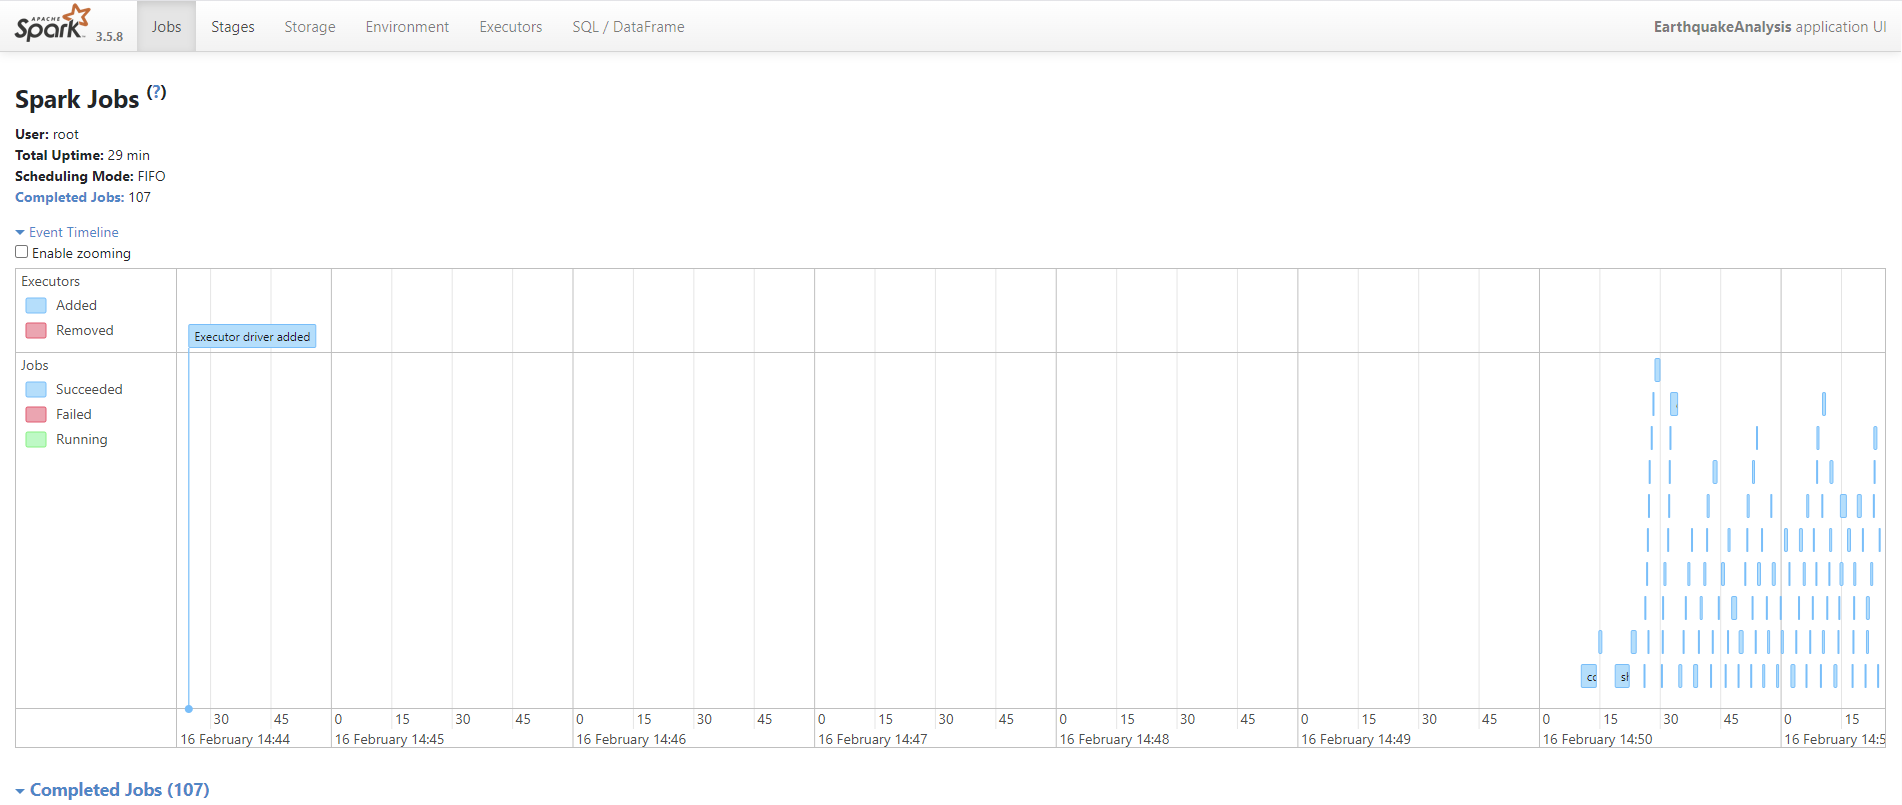

**Completed Jobs List**

The jobs list shows each action that triggered computation. Notice how `count` operations (like our cleaning verification steps) are quick (17ms with skipped stages thanks to caching), while the complex join+aggregation jobs take longer (0.6-0.9s).

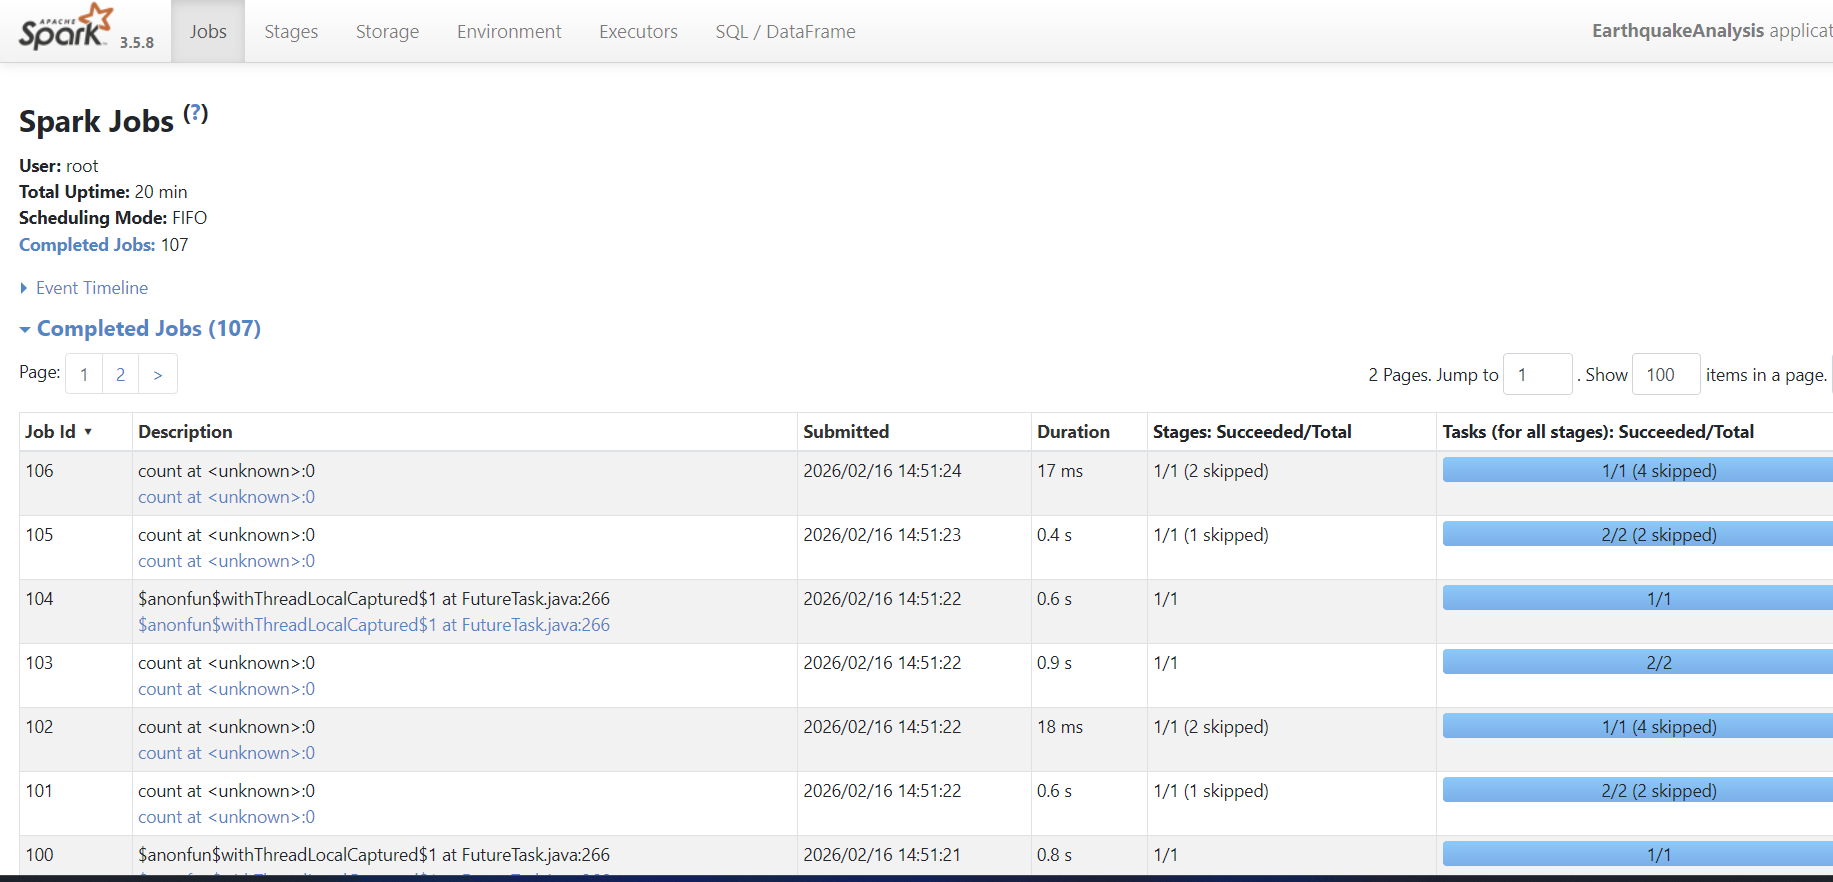

**DAG Visualization: Job 104 (Join + Aggregation)**

This is the DAG for one of our complex queries. It shows Stage 201 with three key operations:

1. **Scan csv**: Spark reads the CSV file from disk. This is a narrow transformation that processes each partition independently.
2. **WholeStageCodegen(2)**: Spark's code generation engine compiles the filter, withColumn, and other narrow transformations into optimized Java bytecode. This is a major performance optimization that avoids the overhead of interpreting each row individually.
3. **BroadcastExchange**: Since the countries DataFrame is small (227 rows), Spark chose a **broadcast join** strategy instead of a shuffle join. It broadcasts the small table to all executors, avoiding an expensive shuffle. This is the Catalyst optimizer making smart decisions automatically.

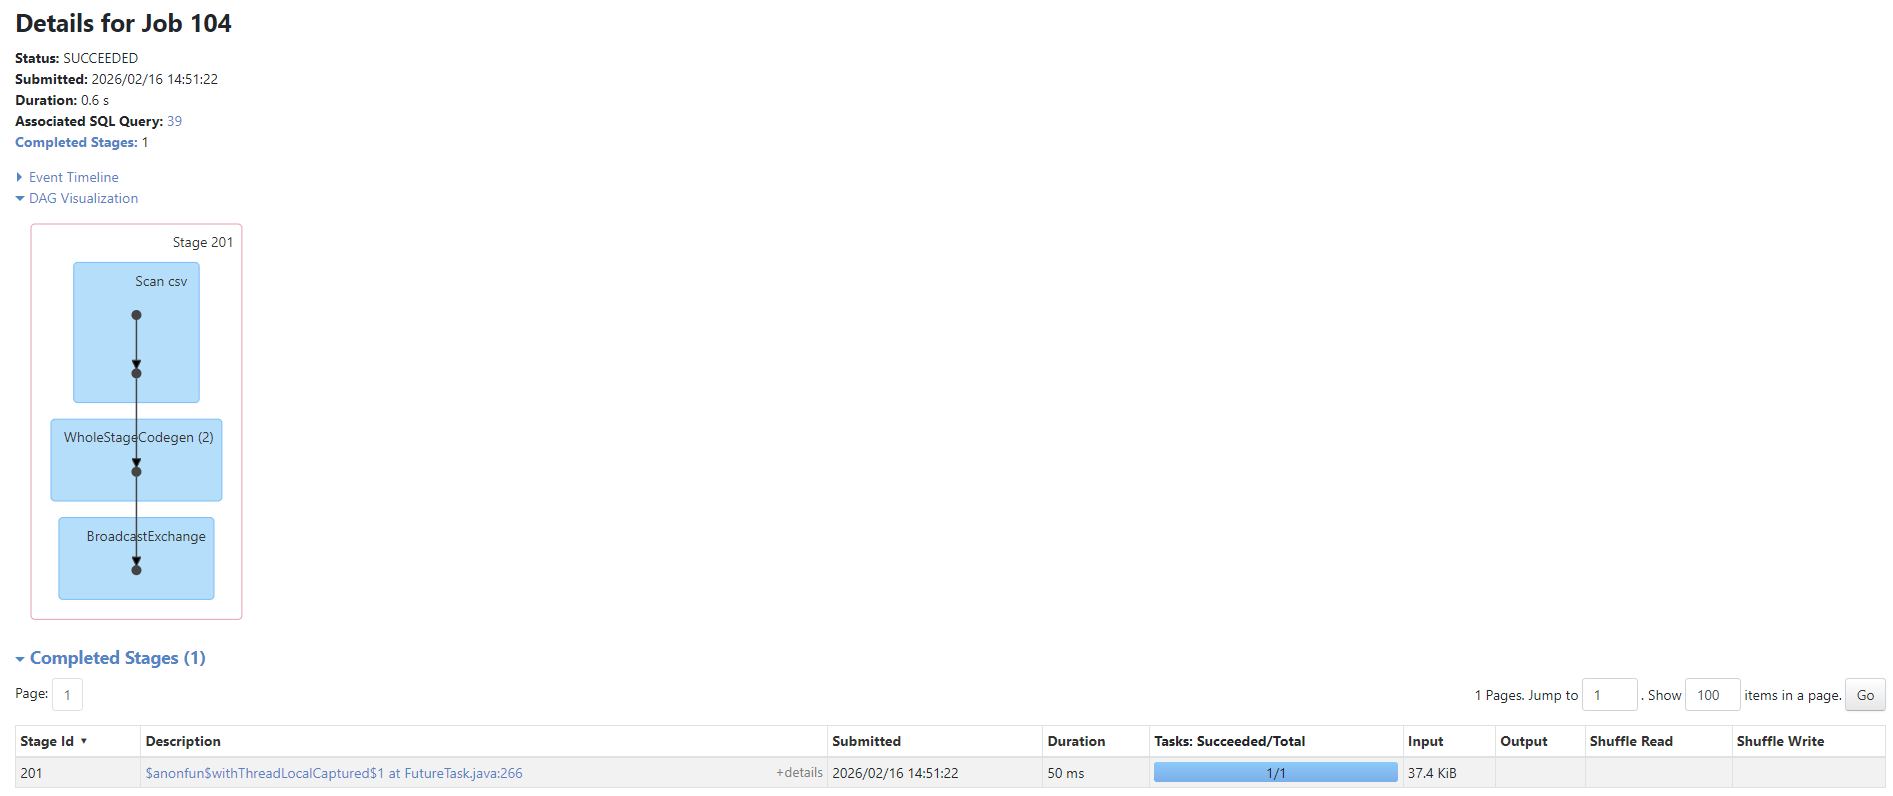

The fact that Spark chose BroadcastExchange here shows the Catalyst optimizer at work (ref Chapter 3.0): it analyzed the data sizes and picked the most efficient join strategy without me having to specify it. A shuffle join would have been much slower for this kind of small-table-to-large-table join.

## 19. Key Findings

Final summary of the key numbers from the analysis.

In [ ]:
# Summary statistics
total = df_enriched.count()
major = df_enriched.filter(col("mag") >= 7.0).count()
great = df_enriched.filter(col("mag") >= 8.0).count()

print("GLOBAL EARTHQUAKE ANALYSIS: KEY FINDINGS")
print(f"Total earthquakes analyzed: {total:,}")
print(f"Major earthquakes (M>=7): {major:,} ({major/total*100:.1f}%)")
print(f"Great earthquakes (M>=8): {great:,} ({great/total*100:.1f}%)")

top = df_enriched.groupBy("Country_Extracted").count().orderBy(col("count").desc()).first()
print(f"\nMost active region: {top['Country_Extracted']} ({top['count']:,} earthquakes)")

deepest = df_enriched.orderBy(col("depth").desc()).first()
print(f"Deepest earthquake: {deepest['depth']:.1f} km: {deepest['place']}")

strongest = df_enriched.orderBy(col("mag").desc()).first()
print(f"Strongest earthquake: M{strongest['mag']:.1f}: {strongest['place']} ({strongest['Year']})")

print(f"\nThis analysis used PySpark DataFrames, Spark SQL,")
print(f"window functions, pivot tables, and joins across 3 datasets.")
print(f"Course references: Labs 3.1-3.12, Chapters 3.0, 4.0")

In [ ]:
# Clean up: stop the Spark session
spark.stop()
print("SparkSession stopped.")

## Conclusion

Through this analysis, I was able to process over 100,000 earthquake records spanning more than a century, and I learned a lot both about PySpark and about seismology.

What surprised me most was that the number of recorded earthquakes has increased dramatically over the decades, but the average magnitude hasn't: meaning we're just getting better at detecting smaller quakes, not that the Earth is becoming more active.

Another interesting finding: there's no seasonal pattern at all. I expected maybe some slight variation, but months are almost perfectly uniform. Earthquakes truly don't care about the calendar.

The join with country data revealed that developing regions in the Pacific (Indonesia, Philippines, Papua New Guinea) face disproportionate seismic risk relative to their GDP, which has real humanitarian implications.

### Techniques I Used

| Technique | Where I Learned It |
|---|---|
| SparkSession and Setup | Lab 3.1 |
| Actions vs Transformations | Lab 3.2, 3.4 |
| Manual Schema Declaration | Lab 3.5 |
| Data Quality and Cleaning | Lab 3.6 |
| Transformations and Calculated Columns | Lab 3.7 |
| Spark SQL | Lab 3.8 |
| Joins and Unions | Lab 3.10 |
| **Window Functions** | *Beyond the course* |
| **Pivot Tables** | *Beyond the course* |

If I had more time, I would explore the geographic clustering of earthquakes using PySpark MLlib's KMeans, and maybe build a simple magnitude prediction model based on location and depth.

*Nolan CACHEUX*